### 🚀 Método: Valores Iniciales Optimistas

**Idea principal:**  
En lugar de iniciar `Q(a)` en cero, se le asignan valores altos (optimistas).  
Esto fuerza al agente a **explorar naturalmente**: probará todas las acciones al inicio para confirmar si realmente son tan buenas como cree.



**Exploración:**  
Surge de manera **implícita**, sin necesidad de usar ε.

**Ventajas:**
- No necesita parámetro ε.  
- Genera exploración inicial sin aleatoriedad.

**Desventajas:**
- Solo funciona bien al inicio del entrenamiento.  
- Si los valores son demasiado altos, puede tardar en estabilizarse.

**Resultado típico:**  
Curvas con picos (“dientes de sierra”) al inicio mientras el agente prueba acciones nuevas, luego se estabiliza cuando encuentra la mejor.


In [8]:
import numpy as np
import matplotlib.pyplot as plt


In [9]:
GRID_SIZE = 5
ACTIONS = {1: "up", 2: "down", 3: "left", 4: "right", 5: "stay"}


In [10]:
def init_positions():
    head = np.random.randint(0, GRID_SIZE, size=2)
    food = np.random.randint(0, GRID_SIZE, size=2)
    while np.array_equal(head, food):
        food = np.random.randint(0, GRID_SIZE, size=2)
    return head, food


In [ ]:
def move(head, action):
    if action == "up": 
        head = head + np.array([-1, 0])
    elif action == "down": 
        head = head + np.array([1, 0])
    elif action == "left": 
        head = head + np.array([0, -1])
    elif action == "right": 
        head = head + np.array([0, 1])
    return head

In [12]:
def get_reward(head, food):
    if np.array_equal(head, food): return 1
    elif np.any(head < 0) or np.any(head >= GRID_SIZE): return -1
    else: return 0

In [13]:
partidas = 1000
turnos = 100
alpha = 0.5
epsilons = [0, 0.1]  # 0 = greedy puro, 0.1 = exploración controlada
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))


In [ ]:
for ej in range(partidas):
    for i, e in enumerate(epsilons):
        # Inicialización optimista
        if e == 0:
            Q = {k: 5 for k in range(1,6)}#fuerza exploración indirecta
        else:
            Q = {k: 0 for k in range(1,6)}

        head, food = init_positions()
        mejor_accion = 1  # comer (arbitrario, para registro)

        for exp in range(turnos):
            # Política ε-greedy
            if np.random.uniform(0,1) < e:
                a = np.random.randint(5) + 1    # acción aleatoria → EXPLORACIÓN
            else:
                maxQ = -100
                for j in range(1, 6):
                    if Q[j] > maxQ:
                        maxQ = Q[j]
                        a = j                   # mejor acción según Q → EXPLOTACIÓN


            # Ejecutar acción
            new_head = move(head.copy(), ACTIONS[a])
            recompensa = get_reward(new_head, food)
            head = new_head

            # Actualización incremental
            Q[a] += alpha * (recompensa - Q[a])

            # Métricas
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

            # Reinicio si come o choca
            if recompensa != 0:
                head, food = init_positions()

recompensas_medias /= partidas
acciones_optimas /= partidas




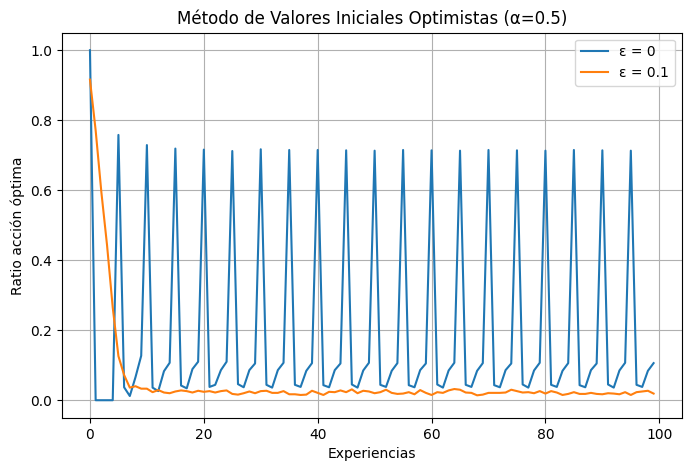

In [15]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(acciones_optimas[i], label=f'ε = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Ratio acción óptima')
plt.title('Método de Valores Iniciales Optimistas (α=0.5)')
plt.show()